In [134]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.stem.porter import PorterStemmer

In [54]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to C:\Users\Manish
[nltk_data]     Kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Manish
[nltk_data]     Kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [55]:
df = pd.read_csv('../Data/raw/mail.csv')
df.head()

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [56]:
df.shape

(5572, 2)

## Data Cleaning

In [57]:
df.isnull().sum()

Category    0
Masseges    0
dtype: int64

In [58]:
df.duplicated().sum()

np.int64(403)

In [59]:
df.drop_duplicates(keep='first',inplace=True)

In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
df.shape

(5169, 2)

## EDA


In [62]:
# change the column name from category to target
df.rename(columns={'Category':'target'},inplace=True)

In [63]:
df['target'].value_counts()

target
ham     4516
spam     653
Name: count, dtype: int64

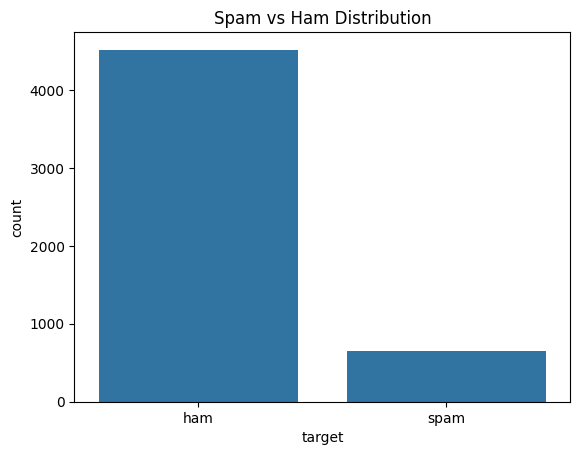

In [64]:
plt.Figure(figsize=(8,5))
sns.countplot(x=df['target'])
plt.title('Spam vs Ham Distribution')
plt.show()

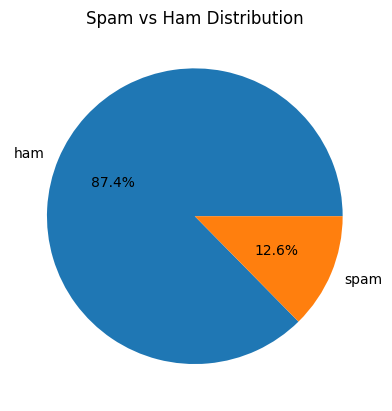

In [65]:
plt.Figure(figsize=(8,5))
df['target'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Spam vs Ham Distribution')
plt.show()

The email dataset exhibits a significant class imbalance, with ham (legitimate emails) comprising approximately 88% of the data and spam representing only 12%. This skewed distribution is typical of real-world email datasets and requires careful consideration during model training using metrics like F1-score and stratified cross-validation rather than accuracy alone

In [66]:
# change the spam and ham to numaric
from sklearn.preprocessing import LabelEncoder
LabelEncoding = LabelEncoder()

df['target'] = LabelEncoding.fit_transform(df['target'])

In [67]:
df['num_characters'] = df['Masseges'].apply(len)

In [68]:
df.head()

,target,Masseges,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [69]:
df['num_words'] = df['Masseges'].apply(lambda x: len(word_tokenize(x)))

In [70]:
df['num_sentences'] = df['Masseges'].apply(lambda x: len(sent_tokenize(x)))

In [71]:
df.head()

,target,Masseges,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [72]:
df[['target','num_characters','num_words','num_sentences']].corr()

,target,num_characters,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

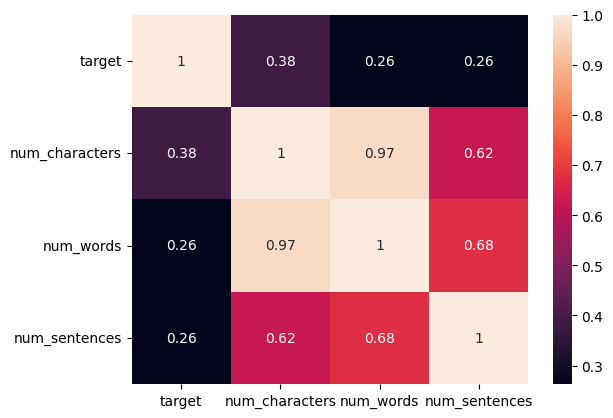

In [73]:
sns.heatmap(df[['target','num_characters','num_words','num_sentences']].corr(),annot=True)

## Data/Text Preprocessing

In [74]:
def text_preprocessing(text):
    # converting to lower
    text = text.lower()
    
    # removing any special characters
    text = re.sub(r'[^a-z0-9\s]', '', text)
    
    # creating tokens
    tokens = word_tokenize(text)
    
    # removing stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    # steamming 
    steamer = PorterStemmer()
    stemmed_tokens = [steamer.stem(word) for word in tokens ]
    
    return " ".join(stemmed_tokens)
    

In [79]:
df['processed_Masseges'] = df['Masseges'].apply(text_preprocessing)

In [80]:
df.head()

,target,Masseges,num_characters,num_words,num_sentences,processed_Masseges
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah dont think goe usf live around though


In [89]:
df[df['target'] == 1]['processed_Masseges']

2       free entri 2 wkli comp win fa cup final tkt 21...
5       freemsg hey darl 3 week word back id like fun ...
8       winner valu network custom select receivea 900...
9       mobil 11 month u r entitl updat latest colour ...
11      six chanc win cash 100 20000 pound txt csh11 s...
                              ...                        
5537    want explicit sex 30 sec ring 02073162414 cost...
5540    ask 3mobil 0870 chatlin inclu free min india c...
5547    contract mobil 11 mnth latest motorola nokia e...
5566    remind o2 get 250 pound free call credit detai...
5567    2nd time tri 2 contact u u 750 pound prize 2 c...
Name: processed_Masseges, Length: 653, dtype: str

### Check most frequent words in spam and ham messages

In [103]:
from wordcloud import WordCloud
word_cloud = WordCloud(width=500,height=500,background_color='white')

In [ ]:
# checking spam words frequecny in dataset
spam_words = word_cloud.generate(df[df['target']==1]['processed_Masseges'].str.cat(sep=" "))
# checking ham/not spam words frequecny in dataset
ham_words = word_cloud.generate(df[df['target']==0]['processed_Masseges'].str.cat(sep=" "))

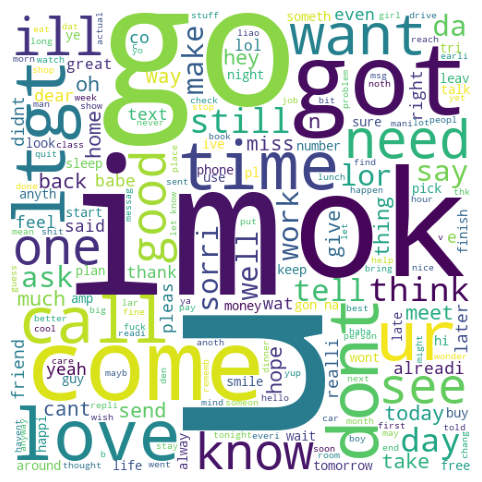

In [101]:
plt.figure(figsize=(10,6))
plt.imshow(spam_words)
plt.axis("off")
plt.show()

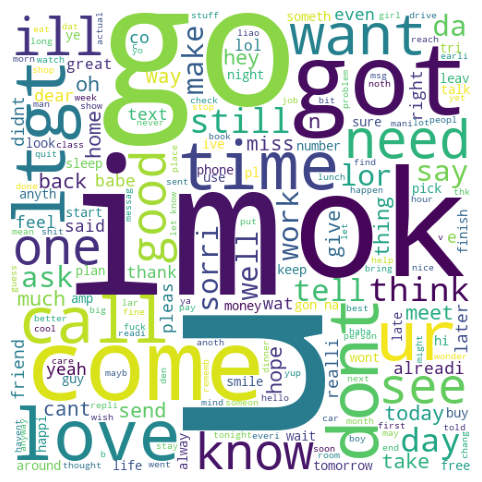

In [102]:
plt.figure(figsize=(10,6))
plt.imshow(ham_words)
plt.axis("off")
plt.show()

The Big piches or big sizes of words showing in graph is most repeated or frequent words in the dataset (spam/not spam) both.

In [106]:
# most common words in spam messages
spam_corpus = []
for msg in df[df['target'] == 1]['processed_Masseges'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [107]:
# most common words in ham/not spams messages
Ham_corpus = []
for msg in df[df['target'] == 0]['processed_Masseges'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [133]:
from collections import Counter
common_spam = pd.DataFrame(
    Counter(spam_corpus).most_common(30)
)


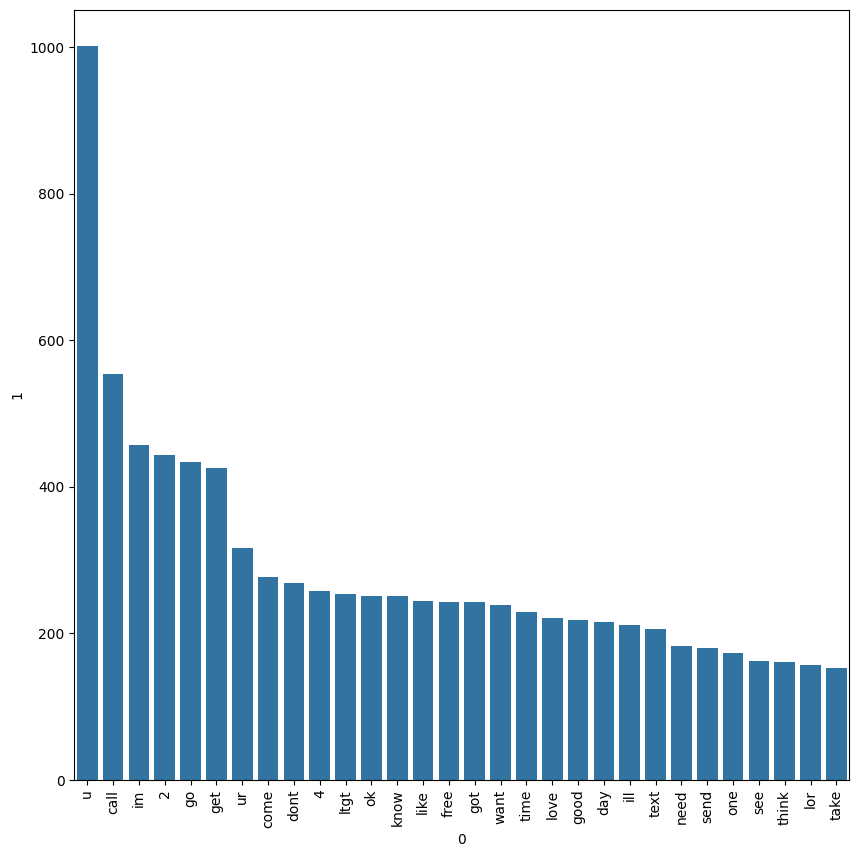

In [129]:
plt.figure(figsize=(10,10))
sns.barplot(x=common_spam[0], y=common_spam[1])
plt.xticks(rotation='vertical')
plt.show()

## Feature Engineering

In [149]:
# Conveting text into the numbers
#Using TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['processed_Masseges']).toarray()

In [148]:
Y = df['target']

In [151]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [152]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [153]:
y_pred = model.predict(X_test)

In [154]:
from sklearn.metrics import accuracy_score, precision_score

print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))

0.9748549323017408
1.0
